In [162]:
import os, warnings
warnings.filterwarnings('ignore')
os.environ['OMP_NUM_THREADS'] = '1'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    roc_auc_score, roc_curve
)
from xgboost import XGBClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
os.makedirs('plots', exist_ok=True)

print('All imports successful.')

All imports successful.


In [163]:
DATA_DIR = 'data' if os.path.exists('data/games.csv') else '../data-ba576project'

games = pd.read_csv(f'{DATA_DIR}/games.csv')
details = pd.read_csv(f'{DATA_DIR}/games_details.csv')
players = pd.read_csv(f'{DATA_DIR}/players.csv')
ranking = pd.read_csv(f'{DATA_DIR}/ranking.csv')
teams = pd.read_csv(f'{DATA_DIR}/teams.csv')

In [165]:
games['GAME_ID'] = games['GAME_ID'].astype(str)
details['GAME_ID'] = details['GAME_ID'].astype(str)
games['GAME_DATE_EST'] = pd.to_datetime(games['GAME_DATE_EST'])

print('Dataset shapes:')
for name, df in [('games', games), ('details', details), ('players', players),
                 ('ranking', ranking), ('teams', teams)]:
    print(f'  {name:>15s}: {df.shape[0]:>7,} rows x {df.shape[1]:>2} cols')

Dataset shapes:
            games:  26,651 rows x 21 cols
          details: 668,628 rows x 29 cols
          players:   7,228 rows x  4 cols
          ranking: 210,342 rows x 13 cols
            teams:      30 rows x 14 cols


In [ ]:
games = games[games['GAME_STATUS_TEXT'].str.lower() == 'final'].copy()
games = games.dropna(subset=['PTS_home', 'PTS_away', 'HOME_TEAM_WINS']).copy()
games['HOME_TEAM_WINS'] = games['HOME_TEAM_WINS'].astype(int)

games = games[
    ~((games['GAME_DATE_EST'].dt.month == 9) |
      ((games['GAME_DATE_EST'].dt.month == 10) &
       (games['GAME_DATE_EST'].dt.day < 15)))
].copy()

games = games[
    ~((games['GAME_DATE_EST'] >= '2020-07-07') &
      (games['GAME_DATE_EST'] <= '2020-10-11'))
].copy()

games = games.sort_values('GAME_DATE_EST').reset_index(drop=True)

print(f'Games after cleaning: {len(games):,}')
print(f'Home win rate: {games["HOME_TEAM_WINS"].mean():.3f}')

Games after cleaning: 25,530
Home win rate: 0.592


In [ ]:
details['MIN'] = details['MIN'].astype(str).str.strip()

details = details[details['MIN'].notna() & (details['MIN'] != '0:00')].copy()

num_cols = ['PTS','FGM','FGA','FG3M','FG3A','FTM','FTA',
            'OREB','DREB','REB','AST','STL','BLK','TO']

for col in num_cols:
    details[col] = pd.to_numeric(details[col], errors='coerce')

details[num_cols] = details[num_cols].fillna(0)

details = details[details['GAME_ID'].isin(games['GAME_ID'])].copy()

In [168]:
team_game_stats = (
    details.groupby(['GAME_ID', 'TEAM_ID'], as_index=False)
    .agg(
        PTS=('PTS', 'sum'),
        FGM=('FGM', 'sum'),
        FGA=('FGA', 'sum'),
        FG3M=('FG3M', 'sum'),
        FG3A=('FG3A', 'sum'),
        FTM=('FTM', 'sum'),
        FTA=('FTA', 'sum'),
        OREB=('OREB', 'sum'),
        DREB=('DREB', 'sum'),
        REB=('REB', 'sum'),
        AST=('AST', 'sum'),
        STL=('STL', 'sum'),
        BLK=('BLK', 'sum'),
        TOV=('TO', 'sum')
    )
)

team_game_stats['FG_PCT'] = np.where(
    team_game_stats['FGA'] > 0,
    team_game_stats['FGM'] / team_game_stats['FGA'],
    0.0
)
team_game_stats['FG3_PCT'] = np.where(
    team_game_stats['FG3A'] > 0,
    team_game_stats['FG3M'] / team_game_stats['FG3A'],
    0.0
)
team_game_stats['FT_PCT'] = np.where(
    team_game_stats['FTA'] > 0,
    team_game_stats['FTM'] / team_game_stats['FTA'],
    0.0
)

print(f'team_game_stats shape: {team_game_stats.shape}')
display(team_game_stats.head())

team_game_stats shape: (51003, 19)


,GAME_ID,TEAM_ID,PTS,FGM,FGA,FG3M,FG3A,FTM,FTA,OREB,DREB,REB,AST,STL,BLK,TOV,FG_PCT,FG3_PCT,FT_PCT
0,10400064,1610612743,105.0,42.0,87.0,4.0,11.0,17.0,23.0,10.0,31.0,41.0,29.0,8.0,3.0,18.0,0.482759,0.363636,0.739130
1,10400064,1610612744,86.0,32.0,79.0,3.0,10.0,19.0,24.0,10.0,29.0,39.0,15.0,7.0,3.0,25.0,0.405063,0.300000,0.791667
2,10400065,1610612757,63.0,19.0,61.0,5.0,23.0,20.0,27.0,14.0,30.0,44.0,9.0,4.0,6.0,29.0,0.311475,0.217391,0.740741
3,10400065,1610612766,69.0,29.0,77.0,3.0,10.0,8.0,14.0,13.0,24.0,37.0,24.0,18.0,3.0,14.0,0.376623,0.300000,0.571429
4,10400066,1610612750,102.0,46.0,88.0,1.0,7.0,9.0,14.0,8.0,38.0,46.0,32.0,8.0,6.0,13.0,0.522727,0.142857,0.642857


In [ ]:
home_rows = games[['GAME_DATE_EST', 'GAME_ID', 'HOME_TEAM_ID', 'VISITOR_TEAM_ID']].copy()
home_rows = home_rows.rename(columns={'HOME_TEAM_ID': 'TEAM_ID', 'VISITOR_TEAM_ID': 'OPP_ID'})
home_rows['IS_HOME'] = 1

away_rows = games[['GAME_DATE_EST', 'GAME_ID', 'HOME_TEAM_ID', 'VISITOR_TEAM_ID']].copy()
away_rows = away_rows.rename(columns={'VISITOR_TEAM_ID': 'TEAM_ID', 'HOME_TEAM_ID': 'OPP_ID'})
away_rows['IS_HOME'] = 0

schedule = pd.concat([home_rows, away_rows], ignore_index=True)

schedule = schedule.merge(
    team_game_stats[['GAME_ID', 'TEAM_ID', 'PTS', 'REB', 'OREB', 'DREB',
                     'AST', 'STL', 'BLK', 'TOV', 'FG_PCT', 'FG3_PCT', 'FT_PCT', 'FTA']]
    .rename(columns={'PTS': 'PTS_SCORED'}),
    on=['GAME_ID', 'TEAM_ID'],
    how='left'
)

opp_pts = team_game_stats[['GAME_ID', 'TEAM_ID', 'PTS']].rename(
    columns={'TEAM_ID': 'OPP_ID', 'PTS': 'PTS_ALLOWED'}
)
schedule = schedule.merge(opp_pts, on=['GAME_ID', 'OPP_ID'], how='left')

schedule = schedule.sort_values(['TEAM_ID', 'GAME_DATE_EST']).reset_index(drop=True)

print(f'Schedule shape: {schedule.shape}')
display(schedule.head())

Schedule shape: (51060, 18)


,GAME_DATE_EST,GAME_ID,TEAM_ID,OPP_ID,IS_HOME,PTS_SCORED,REB,OREB,DREB,AST,STL,BLK,TOV,FG_PCT,FG3_PCT,FT_PCT,FTA,PTS_ALLOWED
0,2003-10-29,20300006,1610612737,1610612740,0,83.0,58.0,10.0,48.0,18.0,7.0,11.0,25.0,0.397590,0.214286,0.736842,19.0,88.0
1,2003-10-31,20300024,1610612737,1610612741,0,94.0,48.0,13.0,35.0,22.0,6.0,7.0,15.0,0.400000,0.583333,0.714286,21.0,100.0
2,2003-11-01,20300029,1610612737,1610612754,1,99.0,36.0,4.0,32.0,23.0,5.0,9.0,16.0,0.467532,0.375000,0.677419,31.0,103.0
3,2003-11-03,20300042,1610612737,1610612740,1,90.0,50.0,18.0,32.0,20.0,6.0,7.0,15.0,0.426829,0.333333,0.652174,23.0,80.0
4,2003-11-05,20300060,1610612737,1610612744,0,72.0,43.0,13.0,30.0,19.0,8.0,4.0,19.0,0.367089,0.333333,0.500000,20.0,99.0


In [279]:
WINDOW = 20
MIN_HISTORY = 20

schedule['WIN'] = (schedule['PTS_SCORED'] > schedule['PTS_ALLOWED']).astype(int)

roll_cols = {
    'PTS_SCORED': 'ROLL_PTS',
    'PTS_ALLOWED': 'ROLL_PTS_ALLOWED',
    'REB': 'ROLL_REB',
    'OREB': 'ROLL_OREB',
    'DREB': 'ROLL_DREB',
    'AST': 'ROLL_AST',
    'STL': 'ROLL_STL',
    'BLK': 'ROLL_BLK',
    'TOV': 'ROLL_TOV',
    'FG_PCT': 'ROLL_FG_PCT',
    'FG3_PCT': 'ROLL_FG3_PCT',
    'FT_PCT': 'ROLL_FT_PCT',
    'FTA': 'ROLL_FTA',
    'WIN': 'ROLL_WIN_PCT'
}

for raw_col, new_col in roll_cols.items():
    schedule[new_col] = (
        schedule.groupby('TEAM_ID')[raw_col]
        .transform(lambda s: s.shift(1).rolling(WINDOW, min_periods=MIN_HISTORY).mean())
    )

schedule['ROLL_NET_RATING'] = schedule['ROLL_PTS'] - schedule['ROLL_PTS_ALLOWED']

print('Rolling stats computed.')
display(schedule.head())

Rolling stats computed.


,GAME_DATE_EST,GAME_ID,TEAM_ID,OPP_ID,IS_HOME,PTS_SCORED,REB,OREB,DREB,AST,...,ROLL_AST,ROLL_STL,ROLL_BLK,ROLL_TOV,ROLL_FG_PCT,ROLL_FG3_PCT,ROLL_FT_PCT,ROLL_FTA,ROLL_WIN_PCT,ROLL_NET_RATING
0,2003-10-29,20300006,1610612737,1610612740,0,83.0,58.0,10.0,48.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2003-10-31,20300024,1610612737,1610612741,0,94.0,48.0,13.0,35.0,22.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2003-11-01,20300029,1610612737,1610612754,1,99.0,36.0,4.0,32.0,23.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2003-11-03,20300042,1610612737,1610612740,1,90.0,50.0,18.0,32.0,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2003-11-05,20300060,1610612737,1610612744,0,72.0,43.0,13.0,30.0,19.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [280]:
rolling_feature_cols = [
    'ROLL_NET_RATING',
    'ROLL_PTS',
    'ROLL_PTS_ALLOWED',
    'ROLL_REB',
    'ROLL_OREB',
    'ROLL_DREB',
    'ROLL_AST',
    'ROLL_STL',
    'ROLL_BLK',
    'ROLL_TOV',
    'ROLL_FG_PCT',
    'ROLL_FG3_PCT',
    'ROLL_FT_PCT',
    'ROLL_FTA',
    'ROLL_WIN_PCT'
]

home_sched = schedule[schedule['IS_HOME'] == 1][['GAME_ID', 'TEAM_ID'] + rolling_feature_cols].copy()
away_sched = schedule[schedule['IS_HOME'] == 0][['GAME_ID', 'TEAM_ID'] + rolling_feature_cols].copy()

home_sched.columns = ['GAME_ID', 'HOME_TEAM_ID'] + [f'HOME_{c}' for c in rolling_feature_cols]
away_sched.columns = ['GAME_ID', 'AWAY_TEAM_ID'] + [f'AWAY_{c}' for c in rolling_feature_cols]

model_df = (
    games[['GAME_ID', 'GAME_DATE_EST', 'HOME_TEAM_ID', 'VISITOR_TEAM_ID', 'HOME_TEAM_WINS', 'SEASON']]
    .merge(home_sched, on=['GAME_ID', 'HOME_TEAM_ID'], how='inner')
    .merge(
        away_sched,
        left_on=['GAME_ID', 'VISITOR_TEAM_ID'],
        right_on=['GAME_ID', 'AWAY_TEAM_ID'],
        how='inner'
    )
)

diff_map = {
    'NET_RATING_DIFF': ('HOME_ROLL_NET_RATING', 'AWAY_ROLL_NET_RATING'),
    'PTS_DIFF': ('HOME_ROLL_PTS', 'AWAY_ROLL_PTS'),
    'PTS_ALLOWED_DIFF': ('HOME_ROLL_PTS_ALLOWED', 'AWAY_ROLL_PTS_ALLOWED'),
    'REB_DIFF': ('HOME_ROLL_REB', 'AWAY_ROLL_REB'),
    'OREB_DIFF': ('HOME_ROLL_OREB', 'AWAY_ROLL_OREB'),
    'DREB_DIFF': ('HOME_ROLL_DREB', 'AWAY_ROLL_DREB'),
    'AST_DIFF': ('HOME_ROLL_AST', 'AWAY_ROLL_AST'),
    'STL_DIFF': ('HOME_ROLL_STL', 'AWAY_ROLL_STL'),
    'BLK_DIFF': ('HOME_ROLL_BLK', 'AWAY_ROLL_BLK'),
    'TOV_DIFF': ('HOME_ROLL_TOV', 'AWAY_ROLL_TOV'),
    'FG_PCT_DIFF': ('HOME_ROLL_FG_PCT', 'AWAY_ROLL_FG_PCT'),
    'FG3_PCT_DIFF': ('HOME_ROLL_FG3_PCT', 'AWAY_ROLL_FG3_PCT'),
    'FT_PCT_DIFF': ('HOME_ROLL_FT_PCT', 'AWAY_ROLL_FT_PCT'),
    'FTA_DIFF': ('HOME_ROLL_FTA', 'AWAY_ROLL_FTA'),
    'WIN_PCT_DIFF': ('HOME_ROLL_WIN_PCT', 'AWAY_ROLL_WIN_PCT')
}

for diff_col, (h_col, a_col) in diff_map.items():
    model_df[diff_col] = model_df[h_col] - model_df[a_col]

feature_cols = list(diff_map.keys())

model_df = model_df.dropna(subset=feature_cols).reset_index(drop=True)

print(f'Final model dataset: {len(model_df):,} rows, {len(feature_cols)} features')
print(f'Home win rate: {model_df["HOME_TEAM_WINS"].mean():.3f}')
display(model_df[feature_cols].describe().round(3))

Final model dataset: 25,383 rows, 15 features
Home win rate: 0.591


,NET_RATING_DIFF,PTS_DIFF,PTS_ALLOWED_DIFF,REB_DIFF,OREB_DIFF,DREB_DIFF,AST_DIFF,STL_DIFF,BLK_DIFF,TOV_DIFF,FG_PCT_DIFF,FG3_PCT_DIFF,FT_PCT_DIFF,FTA_DIFF,WIN_PCT_DIFF
count,25383.000,25383.000,25383.000,25383.000,25383.000,25383.000,25383.000,25383.000,25383.000,25383.000,25383.000,25383.000,25383.000,25383.000,25383.000
mean,-0.063,-0.076,-0.013,-0.045,-0.023,-0.022,-0.027,0.003,-0.004,-0.001,-0.000,0.000,-0.000,-0.035,-0.002
std,7.282,6.773,6.877,3.099,1.988,2.518,2.972,1.447,1.329,1.863,0.025,0.041,0.050,3.836,0.243
min,-27.800,-28.400,-26.000,-14.200,-8.600,-12.600,-13.100,-5.750,-4.900,-8.200,-0.099,-0.183,-0.201,-17.250,-0.800
25%,-5.050,-4.650,-4.650,-2.100,-1.350,-1.700,-2.000,-0.950,-0.900,-1.250,-0.017,-0.026,-0.034,-2.600,-0.150
50%,-0.000,-0.050,-0.050,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-0.000,0.000,0.000,-0.050,0.000
75%,4.800,4.500,4.650,2.000,1.300,1.700,1.900,0.950,0.850,1.250,0.017,0.027,0.033,2.500,0.150
max,26.500,24.550,26.650,12.100,8.650,11.850,13.050,5.550,5.650,8.400,0.100,0.167,0.186,16.650,0.900


In [281]:
#LOGISTIC REGRESSION TRAINING
model_df = model_df.sort_values('GAME_DATE_EST').reset_index(drop=True)

split_idx = int(len(model_df) * 0.8)
train = model_df.iloc[:split_idx]
test  = model_df.iloc[split_idx:]

In [282]:
drop_cols = ['PTS_DIFF', 'PTS_ALLOWED_DIFF']
feature_cols_clean = [c for c in feature_cols if c not in drop_cols]

print(f"Features kept ({len(feature_cols_clean)}):", feature_cols_clean)

X_train = train[feature_cols_clean]
y_train = train['HOME_TEAM_WINS']

X_test = test[feature_cols_clean]
y_test = test['HOME_TEAM_WINS']

Features kept (13): ['NET_RATING_DIFF', 'REB_DIFF', 'OREB_DIFF', 'DREB_DIFF', 'AST_DIFF', 'STL_DIFF', 'BLK_DIFF', 'TOV_DIFF', 'FG_PCT_DIFF', 'FG3_PCT_DIFF', 'FT_PCT_DIFF', 'FTA_DIFF', 'WIN_PCT_DIFF']


In [283]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [284]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {'C': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]}

gs = GridSearchCV(
    LogisticRegression(
        penalty='l1',
        solver='liblinear',
        max_iter=1000,
        class_weight='balanced'
    ),
    param_grid,
    cv=tscv,
    scoring='roc_auc',
    verbose=1
)

gs.fit(X_train_scaled, y_train)

print(f"\nBest C:      {gs.best_params_['C']}")
print(f"Best CV AUC: {gs.best_score_:.4f}")

model = gs.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best C:      0.05
Best CV AUC: 0.6940


In [285]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.6310813472523144
ROC AUC: 0.6715713601804083


In [290]:
#RANDOM FOREST TRAINING
rf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=10, random_state=42)
rf.fit(X_train, y_train)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
print("RF AUC:", roc_auc_score(y_test, y_prob_rf))

RF AUC: 0.6689102745809475


In [291]:
#XGBOOST TRAINING
xgb = XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8
)
xgb.fit(X_train, y_train)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
print("XGB AUC:", roc_auc_score(y_test, y_prob_xgb))

XGB AUC: 0.6650562831100277


In [288]:
coef_df = pd.Series(model.coef_[0], index=feature_cols_clean).sort_values(ascending=False)
print(coef_df)

zeroed = coef_df[coef_df == 0]
if len(zeroed) > 0:
    print(f"\nFeatures zeroed out by L1 ({len(zeroed)}):", list(zeroed.index))
else:
    print("\nNo features were zeroed out at this C value.")

NET_RATING_DIFF    0.552218
WIN_PCT_DIFF       0.230551
BLK_DIFF           0.046001
AST_DIFF           0.005162
DREB_DIFF          0.000000
FTA_DIFF           0.000000
FG_PCT_DIFF       -0.007397
OREB_DIFF         -0.009706
STL_DIFF          -0.011050
TOV_DIFF          -0.014779
FT_PCT_DIFF       -0.015228
FG3_PCT_DIFF      -0.042330
REB_DIFF          -0.049402
dtype: float64

Features zeroed out by L1 (2): ['DREB_DIFF', 'FTA_DIFF']


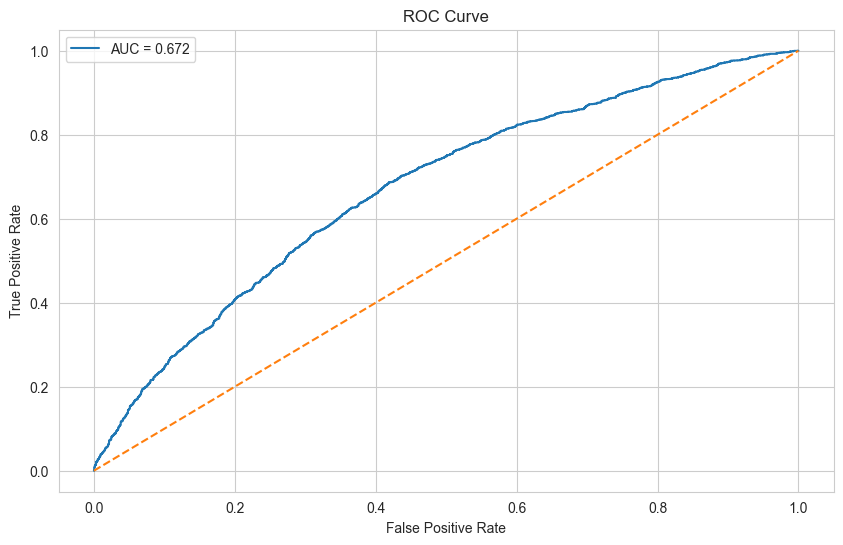

In [289]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

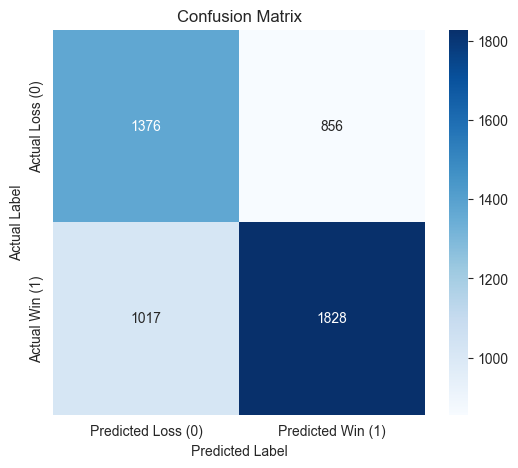

In [231]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Loss (0)', 'Predicted Win (1)'],
            yticklabels=['Actual Loss (0)', 'Actual Win (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

In [232]:
tn, fp, fn, tp = cm.ravel()
print("True Negative Rate (Loss correctly predicted):", tn / (tn + fp))
print("True Positive Rate (Win correctly predicted):",  tp / (tp + fn))

True Negative Rate (Loss correctly predicted): 0.6164874551971327
True Positive Rate (Win correctly predicted): 0.6425307557117751


In [233]:
from sklearn.metrics import precision_score, recall_score

print("Precision:", precision_score(y_test, y_pred))
print("Recall:",    recall_score(y_test, y_pred))

Precision: 0.6810730253353204
Recall: 0.6425307557117751


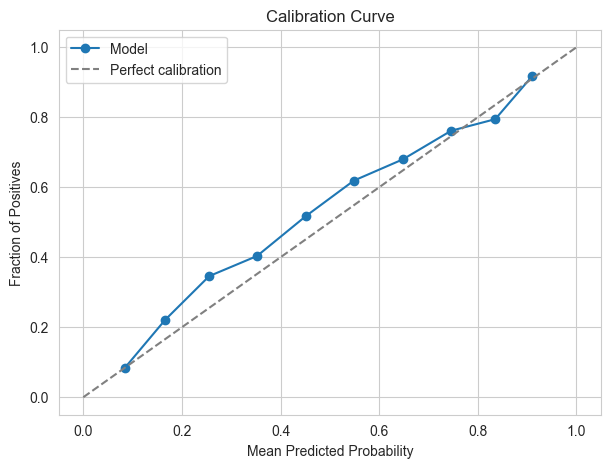

In [218]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred_cal = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(7, 5))
plt.plot(prob_pred_cal, prob_true, marker='o', label='Model')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve')
plt.legend()
plt.show()